# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

   Alpha |    Intercept |        Slope
     0.1 |    -101.7240 |       1.1698
       1 |     -20.5904 |       0.7105
      10 |      -2.2911 |       0.6069
     100 |      -0.2287 |       0.5951
    1000 |      -0.0199 |       0.5928


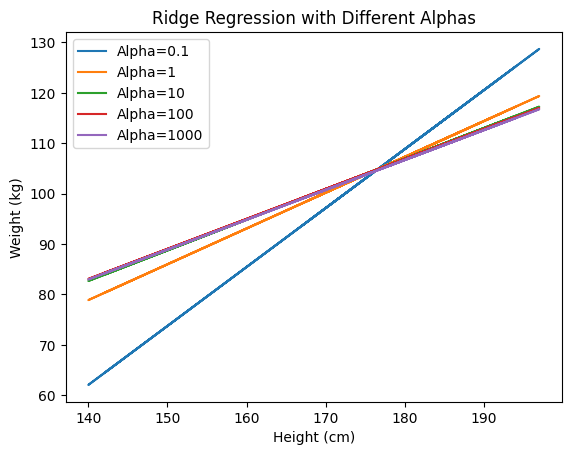

In [7]:
import numpy as np

x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(15, 1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(15, 1)
x = np.asmatrix(np.c_[np.ones((15, 1)), x])
I = np.identity(2)

alphas = [0.1, 1, 10, 100, 1000]

weights = {}
for a in alphas:
    w = np.linalg.inv(x.T * x + a * I) * x.T * y
    weights[a] = w.ravel()

print(f"{'Alpha':>8} | {'Intercept':>12} | {'Slope':>12}")
for a, w in weights.items():
    print(f"{a:8} | {w[0,0]:12.4f} | {w[0,1]:12.4f}")

for a, w in weights.items():
    y_pred = w[0, 0] + w[0, 1] * x[:, 1]
    plt.plot(x[:, 1], y_pred, label=f'Alpha={a}')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('Ridge Regression with Different Alphas')
plt.legend()
plt.show()

## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [18]:
def sgd(x, y, alpha, lr, epochs):
    m, n = x.shape
    w = np.zeros(n)
    
    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        
        for i in indices:
            xi = x[i]
            yi = y[i]
            
            prediction = np.dot(xi, w)
            error = prediction - yi
            
            gradient = error * xi
            l1_penalty = alpha * np.sign(w)
            l1_penalty[0] = 0 
            
            w = w - lr * (gradient + l1_penalty)
            
    return w

In [19]:
x_raw = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(15, 1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(15, 1)

x_bias = np.c_[np.ones((15, 1)), x_raw]

alpha = 0.1 
learning_rate = 0.00001
epochs = 100

w_sgd = sgd(x_bias, y.flatten(), alpha, learning_rate, epochs)

lasso_sk = Lasso(alpha=alpha, fit_intercept=False)
lasso_sk.fit(x_bias, y.flatten())
w_sk = lasso_sk.coef_

print(f"{'Method':<15} | {'Intercept':>12} | {'Slope':>12}")
print("-" * 45)
print(f"{'Manual SGD':<15} | {w_sgd[0]:12.4f} | {w_sgd[1]:12.4f}")
print(f"{'Sklearn Lasso':<15} | {w_sk[0]:12.4f} | {w_sk[1]:12.4f}")

Method          |    Intercept |        Slope
---------------------------------------------
Manual SGD      |      -0.0209 |       0.6667
Sklearn Lasso   |    -168.1947 |       1.5461


## 3. Extend the Fisher's classifier

Please extend the targets of the ``iris_data`` variable and use it as the $y$.

Calculated Weights:
Intercept: -1.3433
Weight for Sepal Width: -0.6378
Weight for Sepal Length: 0.7347


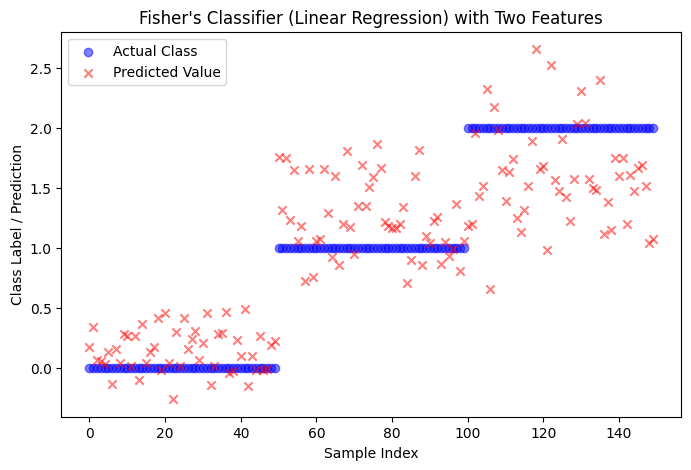

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris_data = load_iris()
iris_df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)

X = iris_df[['sepal width (cm)', 'sepal length (cm)']].values
y = iris_data.target

X_bias = np.c_[np.ones(X.shape[0]), X]

# w = (X^T * X)^-1 * X^T * y
w = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

y_pred = X_bias @ w

print(f"Calculated Weights:")
print(f"Intercept: {w[0]:.4f}")
print(f"Weight for Sepal Width: {w[1]:.4f}")
print(f"Weight for Sepal Length: {w[2]:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(range(len(y)), y, label='Actual Class', color='blue', alpha=0.5)
plt.scatter(range(len(y_pred)), y_pred, label='Predicted Value', color='red', marker='x', alpha=0.5)
plt.xlabel('Sample Index')
plt.ylabel('Class Label / Prediction')
plt.title("Fisher's Classifier (Linear Regression) with Two Features")
plt.legend()
plt.show()